# Data Preparation on Open-Meteo Dataset

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.api.types import is_numeric_dtype
from sklearn.preprocessing import PowerTransformer

from src.compare import compare_transformations
from src.derive import derive_epi
from src.enums import aq_keys, prefixes
from src.serialize import dump_to_file

aq = pd.read_csv('03-26-open-meteo-2023-2026.csv')

## Clean up air quality data

Remove mostly null and non-representative columns from air quality data.

In [2]:
aq_cleaned = aq.copy()
aq_cleaned = aq_cleaned.drop([
    aq_keys['methane (μg/m³)'], # Dropped because half the data is missing.
    aq_keys['carbon_dioxide (ppm)'], # Dropped because half the data is missing.
], axis=1)

aq_preview = aq_cleaned.copy()
aq_columns_with_null = []

for key in aq_preview.columns.tolist():
    null_count = aq_preview[key].isna().sum()
    if null_count > 0:
        aq_columns_with_null.append(key)

print(f"Columns with null values: {len(aq_columns_with_null)}")
aq_preview.head(3)

Columns with null values: 0


,time,us_aqi (USAQI),us_aqi_pm2_5 (USAQI),us_aqi_pm10 (USAQI),us_aqi_nitrogen_dioxide (USAQI),us_aqi_carbon_monoxide (USAQI),us_aqi_ozone (USAQI),us_aqi_sulphur_dioxide (USAQI),uv_index_clear_sky (),uv_index (),dust (μg/m³),aerosol_optical_depth (),ozone (μg/m³),sulphur_dioxide (μg/m³),nitrogen_dioxide (μg/m³),pm2_5 (μg/m³),carbon_monoxide (μg/m³),pm10 (μg/m³)
0,2023-07-01 0:00,45,45,15,14,2,31,2,0.0,0.0,0,0.1,21,3.9,28.8,14.5,246,21.8
1,2023-07-01 1:00,45,45,15,15,2,26,2,0.0,0.0,0,0.1,16,3.6,30.8,14.5,264,21.7
2,2023-07-01 2:00,46,46,15,15,2,21,2,0.0,0.0,0,0.1,14,3.3,31.1,14.2,270,21.1


## Stabilize air quality data

Apply transformation to skewed columns to stabilize variance and make the data more normally distributed.

### Compare skewness across different transformations

In [3]:
compare_transformations(aq_cleaned)

,Original,Square root,Log transformation,Cube root,Yeo-Johnson Transform
time,N/A,N/A,N/A,N/A,N/A
us_aqi (USAQI),0.81,0.33,-0.09,0.18,-0.0
us_aqi_pm2_5 (USAQI),0.39,-0.07,-0.55,-0.23,-0.04
us_aqi_pm10 (USAQI),0.67,0.07,-0.42,-0.13,-0.0
us_aqi_nitrogen_dioxide (USAQI),1.27,0.61,0.13,0.3,0.02
us_aqi_carbon_monoxide (USAQI),1.75,0.84,0.5,0.57,-0.0
us_aqi_ozone (USAQI),0.58,-0.45,-1.32,-0.8,-0.01
us_aqi_sulphur_dioxide (USAQI),1.5,-0.59,-0.16,-1.55,0.01
uv_index_clear_sky (),1.88,1.03,1.08,0.67,0.58
uv_index (),2.04,1.14,1.21,0.75,0.63


In [4]:
transformations = {
    aq_keys['us_aqi (USAQI)']: 'sqrt',
    aq_keys['us_aqi_pm10 (USAQI)']: 'sqrt',
    aq_keys['pm10 (μg/m³)']: 'sqrt',

    aq_keys['us_aqi_nitrogen_dioxide (USAQI)']: 'log1p',
    aq_keys['us_aqi_carbon_monoxide (USAQI)']: 'log1p',
    aq_keys['us_aqi_sulphur_dioxide (USAQI)']: 'log1p',
    aq_keys['sulphur_dioxide (μg/m³)']: 'log1p',
    aq_keys['nitrogen_dioxide (μg/m³)']: 'log1p',
    aq_keys['pm2_5 (μg/m³)']: 'log1p',

    aq_keys['us_aqi_ozone (USAQI)']: 'yeo-johnson',
    aq_keys['carbon_monoxide (μg/m³)']: 'yeo-johnson',
}

aq_transformed = aq_cleaned.copy()

for feature, transformation in transformations.items():
    if transformation == 'sqrt':
        aq_transformed[feature] = np.sqrt(aq_cleaned[feature])
    elif transformation == 'log1p':
        aq_transformed[feature] = np.log1p(aq_cleaned[feature])
    elif transformation == 'yeo-johnson':
        power_transformer = PowerTransformer(method='yeo-johnson')
        aq_transformed[feature] = power_transformer.fit_transform(aq_cleaned[[feature]]).ravel()
        dump_to_file(power_transformer, prefixes['03_30_data_preparation_yeo_johnson_']+feature)

### Skewness comparison

In [5]:
skew_cleaned = {}
skew_transformed = {}
transformations_comparison = {}

for column in aq_transformed.columns:
    if column in transformations:
        transformations_comparison[column] = transformations[column]
    else:
        transformations_comparison[column] = 'None'

for column in aq_transformed.columns:
    if not is_numeric_dtype(aq_cleaned[column]):
        skew_cleaned[column] = 'N/A'
        skew_transformed[column] = 'N/A'
        continue

    skew_cleaned[column] = round(aq_cleaned[column].skew(), 2)
    skew_transformed[column] = round(aq_transformed[column].skew(), 2)

pd.DataFrame({
    'Transformation': transformations_comparison,
    'Skewness (Original)': skew_cleaned,
    'Skewness (Transformed)': skew_transformed
})

,Transformation,Skewness (Original),Skewness (Transformed)
time,None,N/A,N/A
us_aqi (USAQI),sqrt,0.81,0.33
us_aqi_pm2_5 (USAQI),None,0.39,0.39
us_aqi_pm10 (USAQI),sqrt,0.67,0.07
us_aqi_nitrogen_dioxide (USAQI),log1p,1.27,0.13
us_aqi_carbon_monoxide (USAQI),log1p,1.75,0.5
us_aqi_ozone (USAQI),yeo-johnson,0.58,-0.01
us_aqi_sulphur_dioxide (USAQI),log1p,1.5,-0.16
uv_index_clear_sky (),None,1.88,1.88
uv_index (),None,2.04,2.04


### Distribution comparison

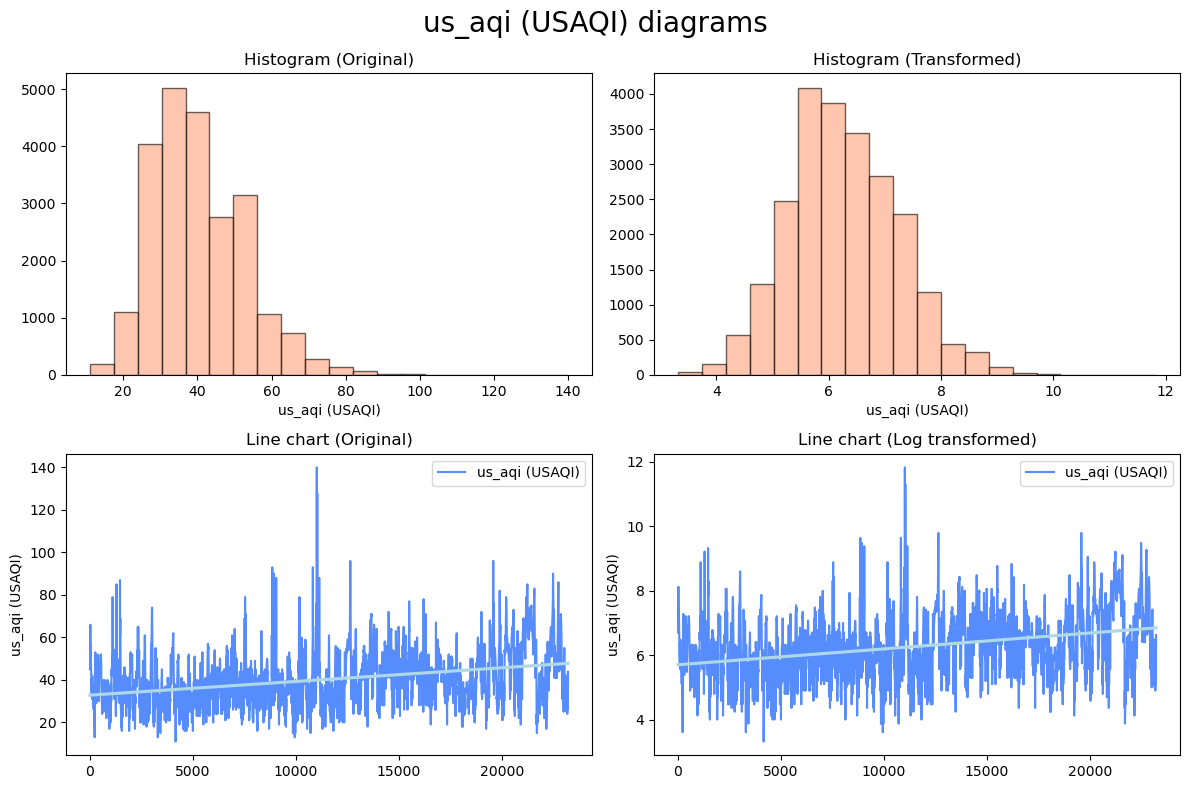

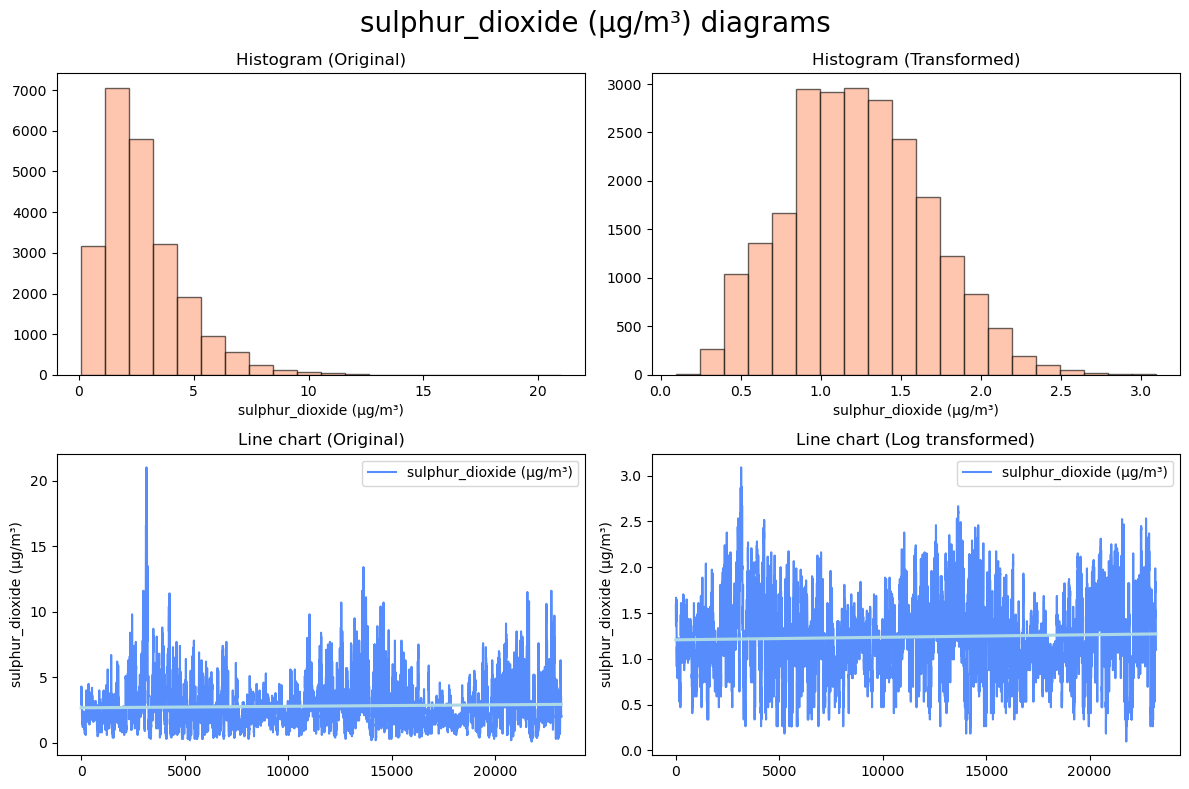

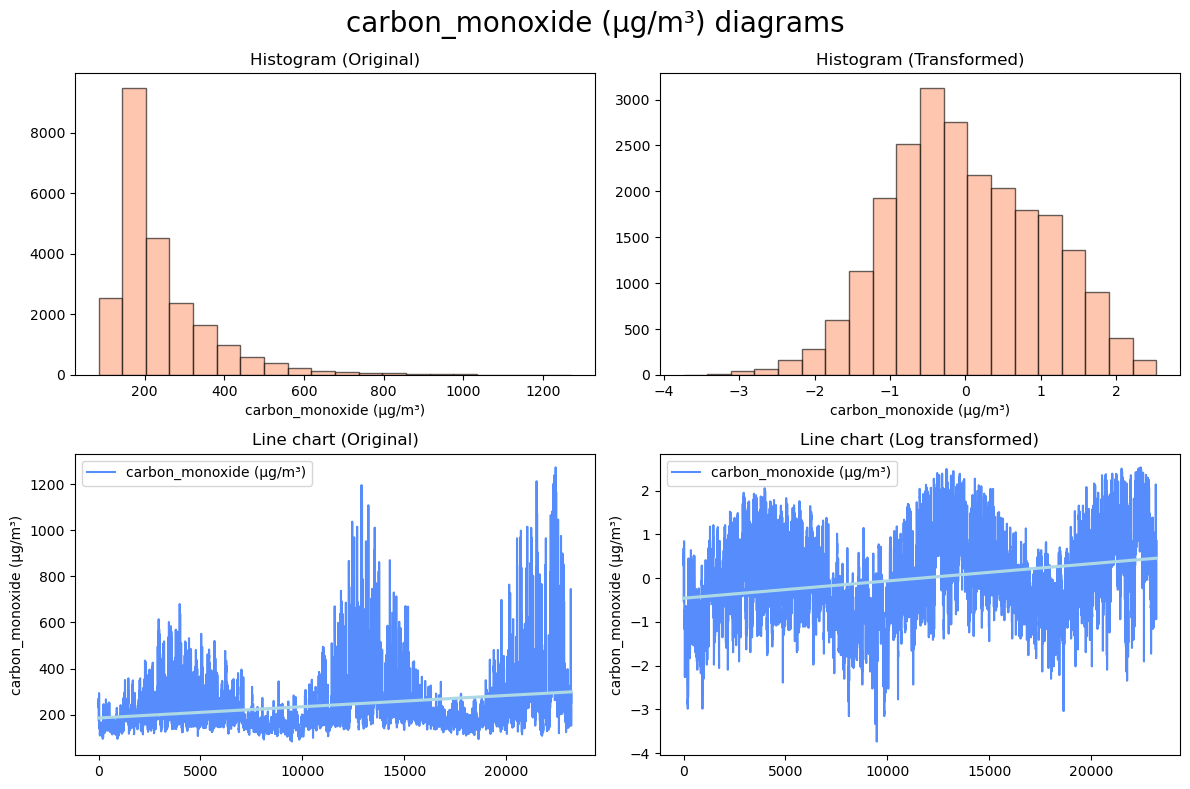

In [6]:
features_comparison = [
    aq_keys['us_aqi (USAQI)'], # square root transformation.
    aq_keys['sulphur_dioxide (μg/m³)'], # log transformation.
    aq_keys['carbon_monoxide (μg/m³)'] # Yeo-Johnson transformation.
]

for feature_comparison in features_comparison:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    plt.suptitle(feature_comparison + ' diagrams', fontsize=20)
    axes[0, 0].hist(aq_cleaned[feature_comparison], alpha = 0.6, bins=20, color='lightsalmon', edgecolor='black')
    axes[0, 0].set_title('Histogram (Original)')
    axes[0, 0].set_xlabel(feature_comparison)

    axes[0, 1].hist(aq_transformed[feature_comparison], alpha = 0.6, bins=20, color='lightsalmon', edgecolor='black')
    axes[0, 1].set_title('Histogram (Transformed)')
    axes[0, 1].set_xlabel(feature_comparison)

    aq_cleaned.plot(y=[feature_comparison], ax=axes[1, 0], title='Line chart (Original)', kind='line')
    sns.regplot(data=aq_cleaned, x=aq_cleaned.index, y=feature_comparison, ax=axes[1,0], scatter=False, color='lightblue')

    aq_transformed.plot(y=[feature_comparison], ax=axes[1,1], title='Line chart (Log transformed)', kind='line')
    sns.regplot(data=aq_transformed, x=aq_transformed.index, y=feature_comparison, ax=axes[1,1], scatter=False, color='lightblue')

    plt.tight_layout()
    plt.show()

## Aggregate air quality data
Aggregate air quality by week to match the granularity of respiratory virus data.

In [7]:
aq_aggregated = aq_transformed.copy()

aq_aggregated[['SEASON', 'WEEKENDING', 'MMWR_WEEK', 'MMWR_YEAR']] = aq_aggregated['time'].apply(lambda x: pd.Series(derive_epi(x)))
aq_aggregated = aq_aggregated.drop([aq_keys['time']], axis=1)
aq_aggregated = aq_aggregated.groupby(['SEASON', 'WEEKENDING', 'MMWR_WEEK', 'MMWR_YEAR']).agg({
    aq_keys['us_aqi (USAQI)']: 'max',
    aq_keys['us_aqi_pm2_5 (USAQI)']: 'max',
    aq_keys['us_aqi_pm10 (USAQI)']: 'max',
    aq_keys['us_aqi_nitrogen_dioxide (USAQI)']: 'max',
    aq_keys['us_aqi_carbon_monoxide (USAQI)']: 'max',
    aq_keys['us_aqi_ozone (USAQI)']: 'max',
    aq_keys['us_aqi_sulphur_dioxide (USAQI)']: 'max',
    aq_keys['uv_index ()']: 'max',
    aq_keys['uv_index_clear_sky ()']: 'max',
    aq_keys['dust (μg/m³)']: 'mean',
    aq_keys['aerosol_optical_depth ()']: 'mean',
    aq_keys['ozone (μg/m³)']: 'mean',
    aq_keys['sulphur_dioxide (μg/m³)']: 'mean',
    aq_keys['nitrogen_dioxide (μg/m³)']: 'mean',
    aq_keys['pm2_5 (μg/m³)']: 'mean',
    aq_keys['carbon_monoxide (μg/m³)']: 'mean',
    aq_keys['pm10 (μg/m³)']: 'mean',
}).reset_index()

aq_preview = aq_aggregated.copy()
aq_preview.head(3)

,SEASON,WEEKENDING,MMWR_WEEK,MMWR_YEAR,us_aqi (USAQI),us_aqi_pm2_5 (USAQI),us_aqi_pm10 (USAQI),us_aqi_nitrogen_dioxide (USAQI),us_aqi_carbon_monoxide (USAQI),us_aqi_ozone (USAQI),...,uv_index (),uv_index_clear_sky (),dust (μg/m³),aerosol_optical_depth (),ozone (μg/m³),sulphur_dioxide (μg/m³),nitrogen_dioxide (μg/m³),pm2_5 (μg/m³),carbon_monoxide (μg/m³),pm10 (μg/m³)
0,2022/2023,07/01/2023,26,2023,8.124038,49,4.000000,2.772589,1.098612,2.868668,...,10.20,10.20,0.416667,0.096250,68.458333,1.493796,2.582966,2.544198,0.180751,4.237535
1,2023/2024,01/06/2024,1,2024,6.403124,41,3.605551,3.332205,1.791759,0.829786,...,2.10,2.20,0.053571,0.067381,41.184524,1.313261,2.886044,1.954268,0.235482,3.161455
2,2023/2024,01/13/2024,2,2024,6.164414,38,3.741657,3.401197,1.386294,0.829786,...,2.05,2.85,0.172619,0.057083,43.684524,1.329416,2.888457,1.787912,0.127957,2.909902


## Checkpoint

In [8]:
aq_aggregated.to_csv('04-01-open-meteo-2023-2026.csv', index=False)